In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings('ignore')

## Plotting
This notebook generates the plots in Dai et al 2025 using simulations generated in another notebook.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d
import pandas as pd
import sncosmo
from scipy import stats
from scipy.special import expit
from nested_pandas import read_parquet
from joblib import Parallel, delayed
from scipy.stats import chi2
import cloudpickle as pickle
from astropy.cosmology import FlatLambdaCDM
from ndtest import ks2d2s
from astropy.time import Time

from lightcurvelynx.astro_utils.mag_flux import mag2flux,flux2mag
from lightcurvelynx.utils.plotting import plot_lightcurves
from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DATA_DIR

from utils.plotting_utils import (plot_snr_distr, 
                                plot_logflux_vs_logfluxerr,
                                plot_logflux_vs_logfluxerr_corner,
                                plot_logmaxflux_vs_logmaxfluxerr,
                                plot_logmaxflux_vs_logmaxfluxerr_corner,
                                convert_flux_to_mag,
                                plot_mag_vs_magerr,
                                convert_flux_to_njy,
                                plot_flux_vs_fluxerr,
                                )

from ztf_snia_sim_params import SIM_PARAMS

from utils.analysis_utils import get_sn_host_sep

import matplotlib
from cycler import cycler

In [4]:
matplotlib.style.use('seaborn-v0_8-paper')

In [5]:
plt.rcParams.update({
    "figure.figsize": (6, 4),
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

In [6]:
H0 = SIM_PARAMS["H0"]
OMEGA_M = SIM_PARAMS["Omega_m"]
ALPHA = SIM_PARAMS["alpha"]
BETA = SIM_PARAMS["beta"]
MAGABS = SIM_PARAMS["mag_abs"]
SIGMA_MAGABS = SIM_PARAMS["sigma_mag_abs"]

#### Read in ZTF SN DR2 data

In [7]:
globalhostdata = pd.read_csv('ztfsniadr2/tables/globalhost_data.csv')
localhostdata = pd.read_csv('ztfsniadr2/tables/localhost_data.csv')
sndata = pd.read_csv('ztfsniadr2/tables/snia_data.csv')
data = pd.merge(sndata,globalhostdata,on='ztfname')

In [8]:
print("Data Redshift Range:",sndata.redshift.min(), sndata.redshift.max())

Data Redshift Range: 0.00245848 0.28779283


In [9]:
print("Data Sample Size:",len(sndata))

Data Sample Size: 3628


In [10]:
lcdata = read_parquet('data/ztfsniadr2.parquet')

In [11]:
t = Time([lcdata['lc.mjd'].min(),lcdata['lc.mjd'].max()], format='mjd', scale='utc')
print("Light Curve MJD Range:")
print(t.to_datetime())

Light Curve MJD Range:
[datetime.datetime(2017, 11, 4, 13, 3, 38, 16000)
 datetime.datetime(2024, 4, 19, 8, 40, 14, 592000)]


#### Read in simulations

In [12]:
lightcurves = read_parquet('results/lightcurves.parquet')

In [13]:
lightcurves = lightcurves.rename(columns={"lightcurve":"lc"})

In [14]:
t = Time([lightcurves['lc.mjd'].min(),lightcurves['lc.mjd'].max()], format='mjd', scale='utc')
print("Sim Light Curve MJD Range:")
print(t.to_datetime())

Sim Light Curve MJD Range:
[datetime.datetime(2018, 6, 19, 4, 7, 30)
 datetime.datetime(2021, 2, 28, 13, 24, 22, 500000)]


In [15]:
lightcurves.head()

id          ra        dec  nobs            t0         z  \
0   0  155.461155  10.812017   411  59093.252822  0.147875   
1   1   74.735729  56.851086  1052   59120.26292  0.150867   
2   2  270.454056   7.358819   678  59171.744427  0.153315   
3   3  175.238461  27.749526   792  58664.600741  0.073493   
4   4   72.007904   4.181395   565  58804.928513  0.153977   

                                              params  source_x0  source_x1  \
0  {'DistModFromRedshift:_distmod_from_redshift_9...    0.00019   0.116075   
1  {'DistModFromRedshift:_distmod_from_redshift_9...   0.000122  -0.476493   
2  {'DistModFromRedshift:_distmod_from_redshift_9...   0.000039  -0.184232   
3  {'DistModFromRedshift:_distmod_from_redshift_9...   0.000937   1.629252   
4  {'DistModFromRedshift:_distmod_from_redshift_9...   0.000141  -0.492835   

   source_c  host_hostmass   source_ra  source_dec     host_ra   host_dec  \
0  0.005235      10.609704  155.461155   10.812017   155.46106  10.812113   
1  0.004102        10.6586   74.735729   56.851086   74.735692  56.850426   
2  0.426158      10.912789  270.454056    7.358819  270.453884   7.358718   
3  0.020544       8.163163  175.238461   27.749526  175.238046  27.750762   
4  -0.01491       9.527334   72.007904    4.181395   72.008002   4.181293   

                                                  lc pass_spec_selection  \
0  [{mjd: 58290.195312, filter: 'g', flux: -9155....               False   
1  [{mjd: 58307.480469, filter: 'g', flux: 3418.6...               False   
2  [{mjd: 58288.3125, filter: 'r', flux: -674.090...               False   
3  [{mjd: 58289.175781, filter: 'g', flux: 3337.4...                True   
4  [{mjd: 58334.480469, filter: 'g', flux: -3527....               False   

  pass_quality_cuts  
0             False  
1             False  
2             False  
3              True  
4             False

In [16]:
print("All sample simulated: nsn=", len(lightcurves))
# drop saturation
lightcurves_after_drop_sat = lightcurves.query("lc.is_saturated==False").dropna()
print("After dropping saturation: nsn=", len(lightcurves_after_drop_sat))
lightcurves_after_detection = lightcurves_after_drop_sat.query("lc.detection_flag == True").dropna()
print("After applying detection: nsn=", len(lightcurves_after_detection))
lightcurves_after_spec_selection = lightcurves.loc[lightcurves['pass_spec_selection']]
print("After spectroscopic selection: nsn=", len(lightcurves_after_spec_selection))
lightcurves_after_quality_cut = lightcurves.loc[lightcurves['pass_quality_cuts']]
print("After quality cuts: nsn=", len(lightcurves_after_quality_cut))

All sample simulated: nsn= 105272
After dropping saturation: nsn= 105272
After applying detection: nsn= 51434
After spectroscopic selection: nsn= 4690
After quality cuts: nsn= 3586


In [17]:
saltpars = pd.read_csv('results/salt3fit_results.csv')
len(saltpars)

3586

In [18]:
saltpars.columns

Index(['id', 'success', 'ncall', 'chisq', 'ndof', 'z', 'z_err', 't0', 't0_err',
       'x0', 'x0_err', 'x1', 'x1_err', 'c', 'c_err', 'mwebv', 'mwebv_err',
       'z_z_cov', 'z_t0_cov', 'z_x0_cov', 'z_x1_cov', 'z_c_cov', 'z_mwebv_cov',
       't0_z_cov', 't0_t0_cov', 't0_x0_cov', 't0_x1_cov', 't0_c_cov',
       't0_mwebv_cov', 'x0_z_cov', 'x0_t0_cov', 'x0_x0_cov', 'x0_x1_cov',
       'x0_c_cov', 'x0_mwebv_cov', 'x1_z_cov', 'x1_t0_cov', 'x1_x0_cov',
       'x1_x1_cov', 'x1_c_cov', 'x1_mwebv_cov', 'c_z_cov', 'c_t0_cov',
       'c_x0_cov', 'c_x1_cov', 'c_c_cov', 'c_mwebv_cov', 'mwebv_z_cov',
       'mwebv_t0_cov', 'mwebv_x0_cov', 'mwebv_x1_cov', 'mwebv_c_cov',
       'mwebv_mwebv_cov', 'fit_error'],
      dtype='object')

In [19]:
## make cuts based on salt parameters
saltpar_cuts = (saltpars.x1 > -3) & (saltpars.x1 < 3)
print("x1 > -3 & x1 < 3: ",np.sum(saltpar_cuts))
saltpar_cuts &= (saltpars.c > -0.2) & (saltpars.c < 0.8)
print("c > -0.2 & x1 < 0.8: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.t0_err < 1
print("sigma_t0 < 1: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.x1_err < 1
print("sigma_x1 < 1: ",np.sum(saltpar_cuts))
saltpar_cuts &= saltpars.c_err < 0.1
print("sigma_c < 0.1: ",np.sum(saltpar_cuts))

reduced = saltpars.chisq / saltpars.ndof
p_value = 1 - chi2.cdf(saltpars.chisq, df=saltpars.ndof)

saltpar_cuts &= p_value > 1e-7
print("fitprob > 1e-7: ",np.sum(saltpar_cuts))


x1 > -3 & x1 < 3:  3499
c > -0.2 & x1 < 0.8:  3432
sigma_t0 < 1:  3329
sigma_x1 < 1:  3301
sigma_c < 0.1:  3279
fitprob > 1e-7:  3264


### Fig. 2

In [20]:
sim_all_x1 = lightcurves['source_x1'].dropna()
sim_all_c = lightcurves['source_c'].dropna()

In [21]:
lc_to_plot = lightcurves_after_quality_cut
sim_x1 = lc_to_plot['source_x1'].dropna()
sim_c = lc_to_plot['source_c'].dropna()

In [22]:
def expo(x, a, b, c):
    x = np.asarray(x)
    y = a * np.exp(b * x) + c
    return y

In [23]:
fx1_parr = np.loadtxt('data/ztf_selection_func_x1.txt')
fc_parr = np.loadtxt('data/ztf_selection_func_c.txt')
fx1_func = lambda x1: expo(x1, *fx1_parr)
fc_func = lambda c: expo(c, *fc_parr)

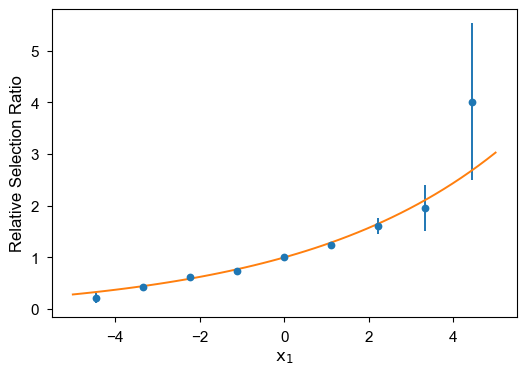

In [24]:
bins = np.linspace(-5,5,10)
x1before,bin_edges,_ = stats.binned_statistic(sim_all_x1,np.ones(len(lightcurves)), statistic='sum', bins=bins)
x1after,bin_edges,_ =  stats.binned_statistic(sim_x1, np.ones(len(lc_to_plot)), statistic='sum', bins=bins)
norm = 1./interp1d((bin_edges[:-1] + bin_edges[1:])/2.,x1after/x1before)(0)
err = np.sqrt(x1after**2/x1before**3 + x1after/x1before**2)
plt.errorbar((bin_edges[:-1] + bin_edges[1:])/2.,x1after/x1before*norm,yerr = err*norm, fmt='o')
xplot = np.linspace(-5,5,50)
plt.plot(xplot,fx1_func(xplot)/fx1_func(0))
plt.xlabel(r'$\mathrm{x_1}$')
plt.ylabel('Relative Selection Ratio')
plt.savefig('paper_figs/x1_selection.png')

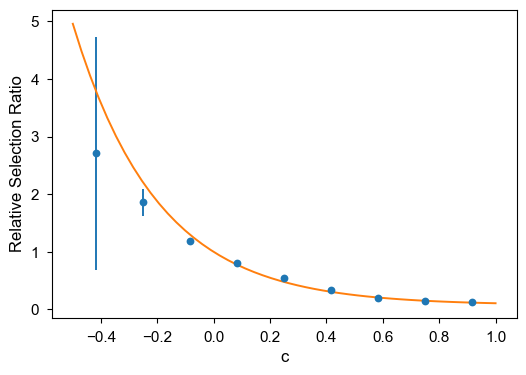

In [25]:
bins = np.linspace(-0.5,1,10)
cbefore,bin_edges,_ = stats.binned_statistic(sim_all_c,np.ones(len(lightcurves)), statistic='sum', bins=bins)
cafter,bin_edges,_ =  stats.binned_statistic(sim_c, np.ones(len(lc_to_plot)), statistic='sum', bins=bins)
norm = 1./interp1d((bin_edges[:-1] + bin_edges[1:])/2.,cafter/cbefore)(0)
err = np.sqrt(cafter**2/cbefore**3 + cafter/cbefore**2)
plt.errorbar((bin_edges[:-1] + bin_edges[1:])/2.,cafter/cbefore*norm,yerr = err*norm, fmt='o')
xplot = np.linspace(-0.5,1,50)
plt.plot(xplot,fc_func(xplot)/fc_func(0))
plt.xlabel('c')
plt.ylabel('Relative Selection Ratio')
plt.savefig('paper_figs/c_selection.png')

### Fig. 4

KstestResult(statistic=np.float64(0.04024220585216776), pvalue=np.float64(0.010116559427914866), statistic_location=np.float64(0.0849729), statistic_sign=np.int8(-1))
Anderson_ksampResult(statistic=np.float64(2.5974617276651744), critical_values=array([0.325, 1.226, 1.961, 2.718, 3.752, 4.592, 6.546]), pvalue=0.02804847111479918)
KLD= 0.017889235445007156


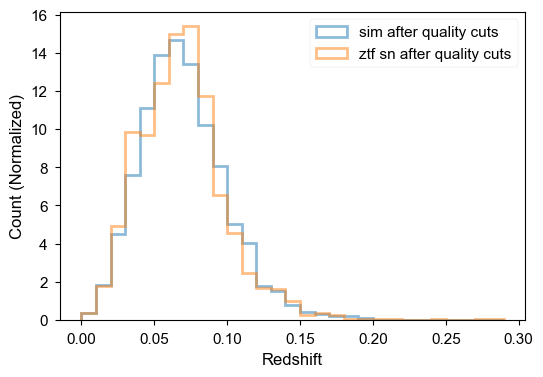

In [26]:
bins=np.linspace(0,0.29,30)
lc_to_plot = lightcurves_after_quality_cut

plt.hist(lc_to_plot['z'],bins=bins,alpha=0.5,density=True,
         histtype='step',label='sim after quality cuts',color='C0',lw=2)
plt.hist(data.loc[data.lccoverage_flag==1].redshift,bins=bins,alpha=0.5,density=True,
         histtype='step',label='ztf sn after quality cuts',color='C1', lw=2)
ks = stats.ks_2samp(lc_to_plot['z'],data.loc[data.lccoverage_flag==1].redshift)
print(ks)
ad = stats.anderson_ksamp([lc_to_plot['z'],data.loc[data.lccoverage_flag==1].redshift])
print(ad)

p1,_ = np.histogram(lc_to_plot['z'],bins=bins,density=True)
p2,_ = np.histogram(data.loc[data.lccoverage_flag==1].redshift,bins=bins,density=True)
p1 = np.clip(p1, 1.e-8, None)
p2 = np.clip(p2, 1.e-8, None)
print("KLD=",stats.entropy(p1,p2))

plt.legend()
plt.xlabel('Redshift')
plt.ylabel('Count (Normalized)')
plt.savefig('paper_figs/z_distr.png')

### Fig. 5

In [27]:
result_df = saltpars

KstestResult(statistic=np.float64(0.03962440108103416), pvalue=np.float64(0.012059445767861783), statistic_location=np.float64(1.325879288699616), statistic_sign=np.int8(-1))
KLD= 0.014172543474349361


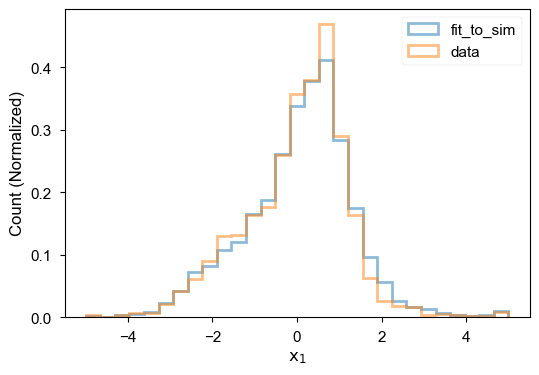

In [28]:
bins=np.linspace(-5,5,30)
# idx = saltpar_cuts
# data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True) & ~data.x1.isna()
idx = np.full(len(result_df), True, dtype=bool)
data_idx = (data.lccoverage_flag == True) & ~data.x1.isna()
    
plt.hist(result_df[idx].x1,bins=bins,density=True,label='fit_to_sim',histtype = 'step',lw = 2, 
         color='C0',alpha=0.5)
plt.hist(data[data_idx].x1,bins=bins,density=True,label='data',histtype = 'step',lw = 2, 
         color='C1',alpha=0.5)
plt.legend()
plt.xlabel(r'$\mathrm{x_1}$')
plt.ylabel('Count (Normalized)')

ks = stats.ks_2samp(result_df[idx].x1,data[data_idx].x1)
print(ks)

p1,_ = np.histogram(result_df[idx].x1,bins=bins,density=True)
p2,_ = np.histogram(data[data_idx].x1,bins=bins,density=True)
p1 = np.clip(p1, 1.e-8, None)
p2 = np.clip(p2, 1.e-8, None)
print("KLD=",stats.entropy(p1,p2))

plt.savefig('paper_figs/x1_distr.png')

KstestResult(statistic=np.float64(0.04173173926086629), pvalue=np.float64(0.006914431458900142), statistic_location=np.float64(0.0375543775343221), statistic_sign=np.int8(-1))
KLD= 0.020077570681059254


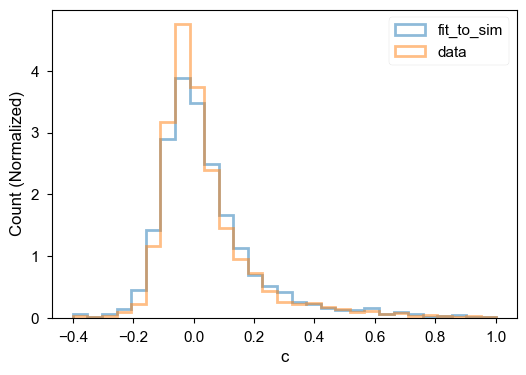

In [29]:
bins=np.linspace(-0.4,1,30)
# idx = saltpar_cuts
# data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True) & ~data.c.isna()
idx = np.full(len(result_df), True, dtype=bool)
data_idx = (data.lccoverage_flag == True) & ~data.x1.isna()

plt.hist(result_df[idx].c,bins=bins,density=True,label='fit_to_sim',histtype = 'step',lw = 2, 
         color='C0',alpha=0.5)
plt.hist(data[data_idx].c,bins=bins,density=True,label='data',histtype = 'step',lw = 2, 
         color='C1',alpha=0.5)
plt.legend()
# plt.title('c')
plt.xlabel('c')
plt.ylabel('Count (Normalized)')

ks = stats.ks_2samp(result_df[idx].c,data[data_idx].c)
print(ks)

p1,_ = np.histogram(result_df[idx].c,bins=bins,density=True)
p2,_ = np.histogram(data[data_idx].c,bins=bins,density=True)
p1 = np.clip(p1, 1.e-8, None)
p2 = np.clip(p2, 1.e-8, None)
print("KLD=",stats.entropy(p1,p2))

plt.savefig('paper_figs/c_distr.png')

### Fig. 6

In [30]:
lc_to_fit = lightcurves_after_quality_cut

In [31]:
merged = lc_to_fit.merge(result_df,on='id')

3264
2666
KS: 0.9999999999999868 0.07142857142857142
KLD= 0.08388419775954145


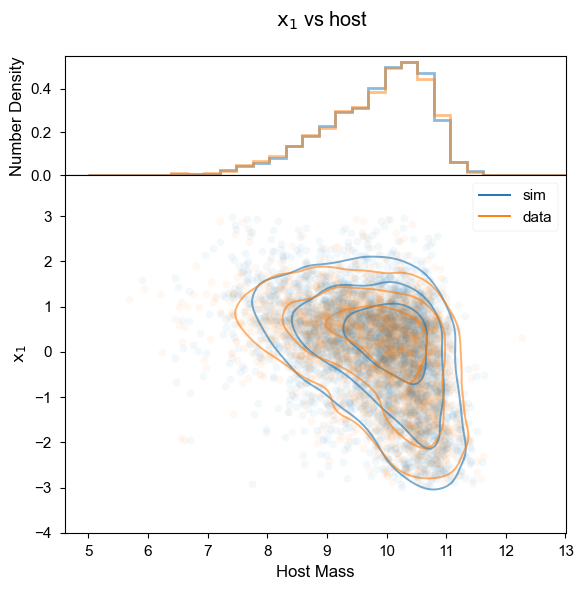

In [32]:
idx = saltpar_cuts
data_idx = (data.fitquality_flag == True) & (data.lccoverage_flag == True)
print(np.sum(idx))
print(np.sum(data_idx))

fig, (ax, ax2) = plt.subplots(2, 1,
                            gridspec_kw={'height_ratios': [1, 3]},   # top is 3x taller than bottom
                            figsize=(6, 6),sharex=True)
hostmass = merged.host_hostmass
x1 = merged.x1
c = merged.c
bins = np.linspace(5,13,30)
ax.hist(hostmass,bins=bins,density=True,label='sim',histtype = 'step',lw = 2, color='C0',alpha=0.5)
ax.hist(data.loc[data.lccoverage_flag == 1].mass,bins=bins,density=True,label='data',histtype = 'step',
        lw = 2, color='C1',alpha=0.5)
ax.set_ylabel('Number Density')

ax2.plot(np.array(hostmass)[idx],np.array(x1)[idx],'o',label='sim',alpha=0.05,color='C0')
ax2.plot(data[data_idx].mass,data[data_idx].x1,'o',label='ztf sn data release',alpha=0.05,color='C1')
ax2.legend()
plt.suptitle(r"$\mathrm{x_1}$ vs host",x=0.55)
# plt.show()

# plt.subplot(2,1,2)
bins_x1 = np.linspace(-4,4,15)
bins_hostmass = np.linspace(6,13,15)

data_plot = data[data_idx]
sim_host = np.array(hostmass)
sim_x1 = np.array(x1)

binwidth_host = bins_hostmass[1]-bins_hostmass[0]
binwidth_x1 = bins_x1[1]-bins_x1[0]

sim_count,sim_x_edges,sim_y_edges, _ = stats.binned_statistic_2d(sim_host,sim_x1,
                                             np.ones(len(sim_host)),
                                             statistic='sum',bins=[bins_hostmass,bins_x1])
data_count,data_x_edges,data_y_edges,_ = stats.binned_statistic_2d(data_plot.mass,data_plot.x1,
                                         np.ones(len(data_plot.mass)),
                                         statistic='sum',bins=[bins_hostmass,bins_x1])
sim_x = 0.5* (sim_x_edges[:-1]+sim_x_edges[1:])
sim_y = 0.5* (sim_y_edges[:-1]+sim_y_edges[1:])
data_x = 0.5* (data_x_edges[:-1]+data_x_edges[1:])
data_y = 0.5* (data_y_edges[:-1]+data_y_edges[1:])
# sim_x_plot,sim_y_plot = np.meshgrid(sim_x, sim_y)
# data_x_plot,data_y_plot = np.meshgrid(data_x, data_y)
# CS = ax2.contour(sim_x_plot.T,sim_y_plot.T,sim_count/np.sum(sim_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='blue')
# CS = ax2.contour(data_x_plot.T,data_y_plot.T,data_count/np.sum(data_count)/binwidth_host/binwidth_x1,alpha=0.5,levels=[0.01,0.05,0.1],colors='red')
# proxies = [Line2D([],[],color=c) for c in ['blue','red']]
# plt.legend(proxies,['sim', 'data'])
# plt.xlabel('host mass')
# plt.ylabel('x1')
# plt.ylim((-4,4))


# ----------------------------------------------------------------------
# Settings: bin ranges (also used for KDE grid)
# ----------------------------------------------------------------------
bins_x1       = np.linspace(-4, 4, 15)
bins_hostmass = np.linspace(6, 13, 15)

x1_min, x1_max           = bins_x1[0],       bins_x1[-1]
hostmass_min, hostmass_max = bins_hostmass[0], bins_hostmass[-1]

# Resolution of KDE grid
nx = 100
ny = 100

# Mask out NaN/inf
mask_sim = np.isfinite(sim_host) & np.isfinite(sim_x1)
sim_host_clean = sim_host[mask_sim]
sim_x1_clean   = sim_x1[mask_sim]

# Data arrays
data_mass = data_plot.mass.to_numpy()
data_x1   = data_plot.x1.to_numpy()

mask_data = np.isfinite(data_mass) & np.isfinite(data_x1)
data_mass_clean = data_mass[mask_data]
data_x1_clean   = data_x1[mask_data]

# ----------------------------------------------------------------------
# Build KDEs
# ----------------------------------------------------------------------
# Sim KDE
values_sim = np.vstack([sim_host_clean, sim_x1_clean])  # shape (2, N)
kde_sim = stats.gaussian_kde(values_sim)

# Optional: tweak bandwidth (e.g., smoother by factor 1.2)
# kde_sim.set_bandwidth(bw_method=lambda *args, **kwargs: 1.2 * kde_sim.scotts_factor())

# Data KDE
values_data = np.vstack([data_mass_clean, data_x1_clean])
kde_data = stats.gaussian_kde(values_data)

# Optional: tweak bandwidth separately for data
# kde_data.set_bandwidth(bw_method=lambda *args, **kwargs: 1.0 * kde_data.scotts_factor())

# ----------------------------------------------------------------------
# Evaluate KDEs on a common grid
# ----------------------------------------------------------------------
host_grid = np.linspace(hostmass_min, hostmass_max, nx)  # x-axis
x1_grid   = np.linspace(x1_min,       x1_max,       ny)  # y-axis

H, X = np.meshgrid(host_grid, x1_grid)  # H: host mass, X: x1
positions = np.vstack([H.ravel(), X.ravel()])  # shape (2, nx*ny)

Z_sim  = kde_sim(positions).reshape(H.shape)   # PDF sim
Z_data = kde_data(positions).reshape(H.shape)  # PDF data

# ----------------------------------------------------------------------
# Choose contour levels (using percentiles so it adapts to your data)
# ----------------------------------------------------------------------
# You can tune these percentiles for how "central" the contours are
sim_levels_percentiles  = [80, 90, 97]
data_levels_percentiles = [80, 90, 97]

sim_levels  = np.percentile(Z_sim,  sim_levels_percentiles)
data_levels = np.percentile(Z_data, data_levels_percentiles)

# ----------------------------------------------------------------------
# Plot
# ----------------------------------------------------------------------

CS_sim = ax2.contour(
    host_grid, x1_grid, Z_sim,
    levels=sim_levels, colors='C0', alpha=0.6
)
CS_data = ax2.contour(
    host_grid, x1_grid, Z_data,
    levels=data_levels, colors='C1', alpha=0.6
)

# Legend using proxy artists
proxies = [Line2D([], [], color=c) for c in ['C0', 'C1']]
ax2.legend(proxies, ['sim', 'data'])

ax2.set_xlabel('Host Mass')
ax2.set_ylabel(r"$\mathrm{x_1}$")
ax2.set_ylim(-4, 3.9)

fig.tight_layout()
fig.subplots_adjust(hspace=0)
fig.savefig('paper_figs/host_x1.png')

p,D = ks2d2s(sim_x,sim_y,data_x,data_y,extra=True)
print("KS:",p,D)

print("KLD=",stats.entropy(Z_sim,Z_data,axis=None))

### Fig. 7

In [33]:
# data quality flags

# from https://github.com/ZwickyTransientFacility/ztfcosmo/blob/260e136be064708e1238719880ce18844027422e/ztfcosmo/lightcurve.py#L111
# flagout: [list of int or string]
#     flag == 0 means all good, but may not be detected:
    
#     0: no warning 
#     1: flux_err==0 Remove unphysical errors 
#     2: chi2dof>3: Remove extreme outliers 
#     4: cloudy>1: BTS cut 
#     8: infobits>0: BTS cut 
#     16: mag_lim<19.3: Cut applied in Dhawan 2021 
#     32: seeing>3: Cut applied in Dhawan 2021 
#     64: fieldid>879: Recommended IPAC cut 
#     128: moonilf>0.5: Recommended IPAC cut 
#     256: has_baseline>1: Has a valid baseline correction 
#     512: airmass>2: Recommended IPAC cut 
#     1024: flux/flux_err>=5: Nominal detection

In [34]:
# ztf sndr2 flags
# sn_type SNIa classification 
# sub_type sub classification if any. 
# lccoverage_flag passes the good sampling cut (bool,Table1) 
# fitquality_flag passes all other Basic cuts (bool,Table1)

In [35]:
def filter_flags(lc_flag, flags_to_exclude=[], flags_to_include=[]):
    pass_filter = True
    if len(flags_to_include)>0:
        pass_filter &= np.all([lc_flag & flag != 0 for flag in flags_to_include])
    if len(flags_to_exclude)>0:
        pass_filter &= np.all([lc_flag & flag == 0 for flag in flags_to_exclude])
    return pass_filter

In [36]:
#calculate this first
lcdata["lc.pass_flag_filter"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[8],flags_to_include=[])
lcdata["lc.pass_detection"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[],flags_to_include=[1024])

lcdata['lc.snr'] = lcdata['lc.flux']/lcdata['lc.flux_err']
lcdata["lc.pass_snr_detection"] = lcdata["lc.snr"] > 5

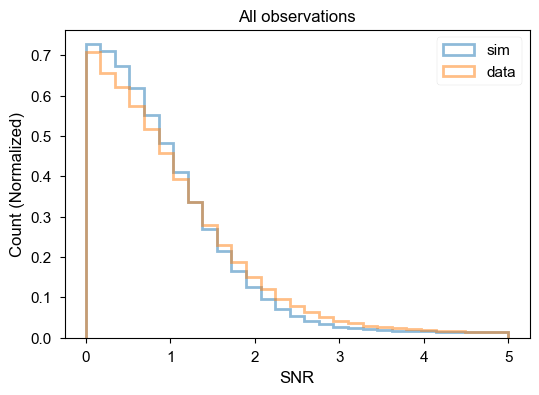

In [37]:
lc_to_plot = lightcurves.loc[lightcurves_after_spec_selection.index]
lcdata_plot = lcdata

bins = np.linspace(0,5,30)

plot_snr_distr([lc_to_plot, lcdata_plot],bins=bins,density=True,
               histtype='step',labels=['sim','data'],lw=2,alpha=0.5)
plt.xlabel('SNR')
plt.ylabel('Count (Normalized)')
plt.title('All observations')
plt.savefig('paper_figs/snr_allobs.png')

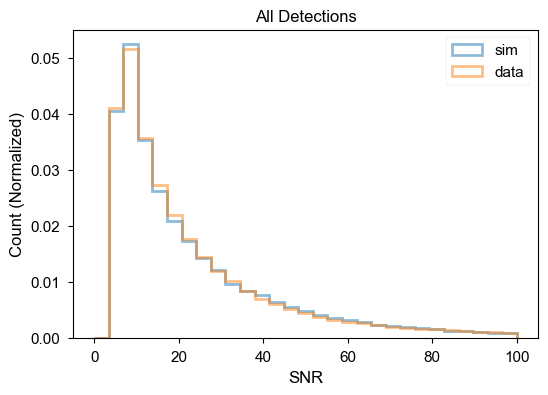

In [38]:
lc_to_plot = lightcurves_after_detection.loc[lightcurves_after_spec_selection.index]

# lcdata["lc.pass_flag_filter"] = lcdata["lc.flag"].apply(filter_flags,flags_to_exclude=[1,2,4,8,16,32,64,128,256,512],flags_to_include=[1024])
lcdata_plot = lcdata.query("lc.pass_flag_filter == True & lc.pass_detection == True & lc.pass_snr_detection == True").dropna(subset="lc")

bins = np.linspace(0,100,30)

plot_snr_distr([lc_to_plot, lcdata_plot],bins=bins,density=True,
               histtype='step',labels=['sim','data'],lw=2,alpha=0.5)
plt.xlabel('SNR')
plt.ylabel('Count (Normalized)')
plt.title('All Detections')
plt.savefig('paper_figs/snr_alldetection.png')

### Fig. 8

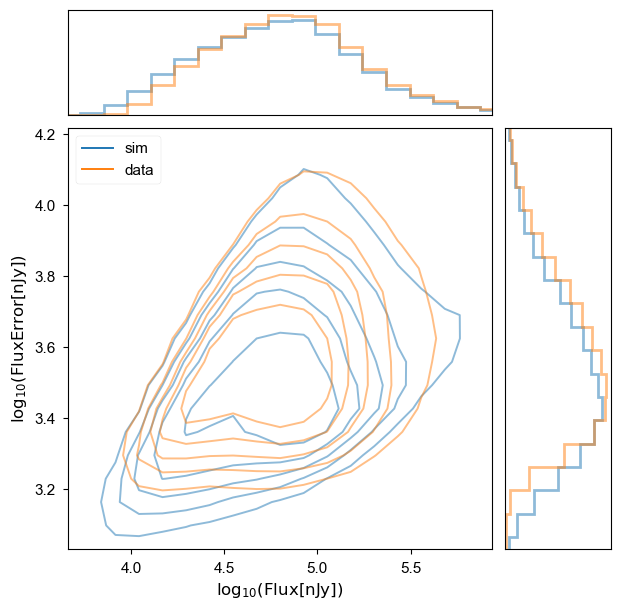

In [39]:
plot_logflux_vs_logfluxerr_corner(lc_to_plot, lcdata_plot, smooth_sigma=0.6)
plt.savefig('paper_figs/logflux_contour.png')

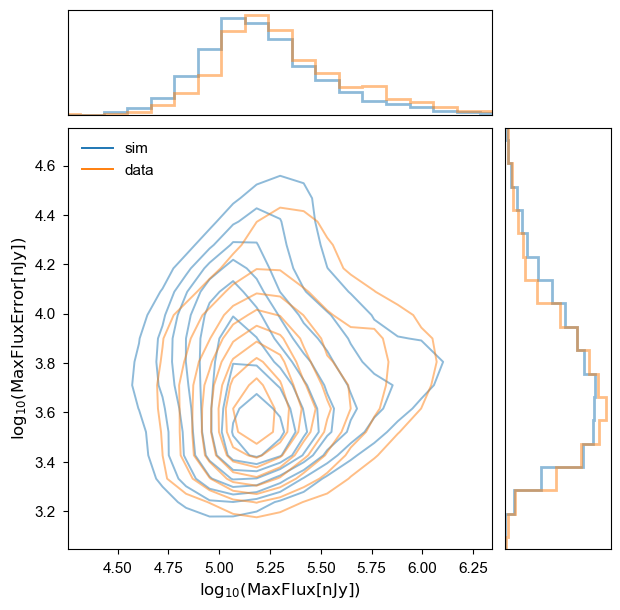

In [40]:
plot_logmaxflux_vs_logmaxfluxerr_corner(lc_to_plot,lcdata_plot,n_levels=10,smooth_sigma=0.8)
plt.savefig('paper_figs/logmaxflux_contour.png')

### Fig. 9

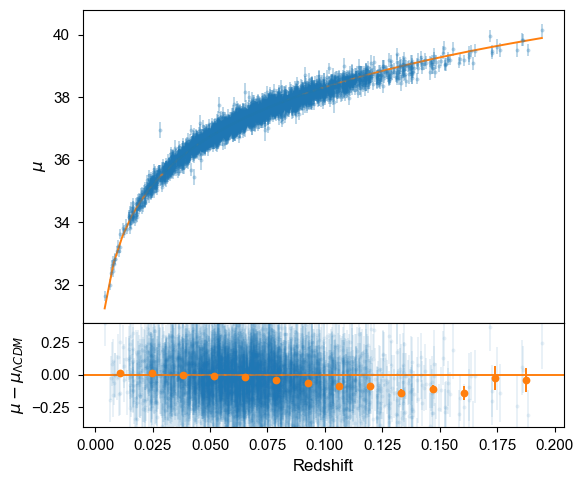

In [41]:
# make HD

x1_hd = result_df.loc[saltpar_cuts,"x1"]
c_hd = result_df.loc[saltpar_cuts,"c"]
x0_hd = result_df.loc[saltpar_cuts,"x0"]
z_hd = result_df.loc[saltpar_cuts,"z"]

x1_err = result_df.loc[saltpar_cuts,"x1_err"]
c_err = result_df.loc[saltpar_cuts,"c_err"]
x0_err = result_df.loc[saltpar_cuts,"x0_err"]

mb_hd = -2.5*np.log10(x0_hd) + 10.635
mb_err = 2.5/np.log(10) * (x0_err/x0_hd)

alpha = ALPHA
beta = BETA
Mb = MAGABS
mu_hd = mb_hd + alpha*x1_hd - beta*c_hd - Mb
mu_err = np.sqrt(mb_err**2 + alpha**2*x1_err**2 + beta**2*c_err**2 + SIGMA_MAGABS**2)

fig, (ax1, ax2) = plt.subplots(2, 1,
                            gridspec_kw={'height_ratios': [3, 1]},   # top is 3x taller than bottom
                            figsize=(6, 5),sharex=True)

ax1.errorbar(z_hd, mu_hd, yerr=mu_err,fmt='.',alpha=0.3)

z_cosmo = np.linspace(z_hd.min(),z_hd.max(),50)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
mu_cosmo = cosmo.distmod(z_cosmo)
ax1.plot(z_cosmo, mu_cosmo)

ax1.set_ylabel(r'$\mu$')

mures = mu_hd - cosmo.distmod(z_hd).value

# ax2 = plt.subplot(3,1,2, sharex=ax1)
ax2.errorbar(z_hd, mures, yerr=mu_err, fmt='.',alpha=0.1)
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
ax2.axhline(y=0,color=colors[1])
ax2.set_ylim((-0.4,0.4))
ax2.set_ylabel(r'$\mu - \mu_{\Lambda CDM}$')
ax2.set_xlabel('Redshift')

bins= np.linspace(z_hd.min(),z_hd.max(),15)
mures_mean, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='mean', bins= bins
)

mures_std, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='std', bins= bins
)

mures_count, bin_edges, _ = stats.binned_statistic(
    z_hd, mures, statistic='count', bins= bins
) 

mures_err = mures_std / np.sqrt(mures_count)

bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
ax2.errorbar(bin_mean, mures_mean, yerr = mures_err,fmt='o')

# ax3 = plt.subplot(3,1,3, sharex=ax1)
# ax3.errorbar(bin_mean, mures_mean, yerr = mures_err,fmt='o')
# ax3.axhline(y=0,color=colors[1])
# ax3.set_ylim((-0.2,0.2))
fig.tight_layout()
fig.subplots_adjust(hspace=0)

plt.savefig('paper_figs/HD.png')

In [42]:
print(f"mures RMS: {np.sqrt(np.mean(mures**2))}")
print(f"mures STD: {np.std(mures)}")

mures RMS: 0.1843456154392053
mures STD: 0.18145539870707192


In [43]:
def make_bined_mures_par_plot(cut):
    nbins = 15
    bins_hostmass = np.linspace(7,12,nbins)
    bins_x1 = np.linspace(-3,3,nbins)
    bins_c = np.linspace(-0.2,0.8,nbins)
    bins_arr = [bins_hostmass,bins_x1,bins_c]
    
    fig = plt.figure(figsize=(6,5))
    i=0
    label_map = {'host_hostmass': 'Host Mass',
                 'x1': r'$\mathrm{x_1}$',
                 'c': 'c'}
    for bins, par in zip(bins_arr,['host_hostmass','x1','c']):
        i = i+1 
        fig.add_subplot(3,1,i)
        x_plot = merged[cut][par]
        x_mean, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='mean', bins= bins
        )
        
        x_std, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='std', bins= bins
        )
        
        x_count, bin_edges, _ = stats.binned_statistic(
            x_plot, mures[cut], statistic='count', bins= bins
        ) 
    
        x_err = x_std / np.sqrt(x_count)
        
        bin_mean = (bin_edges[:-1] + bin_edges[1:])*0.5
        plt.errorbar(bin_mean, x_mean, yerr =x_err,fmt='o')
    
        plt.axhline(y=0,ls=':',c='gray')
        plt.xlabel(label_map[par])
        plt.ylabel(r'$\mu - \mu_{\Lambda CDM}$')
    fig.tight_layout()

### Fig. 10

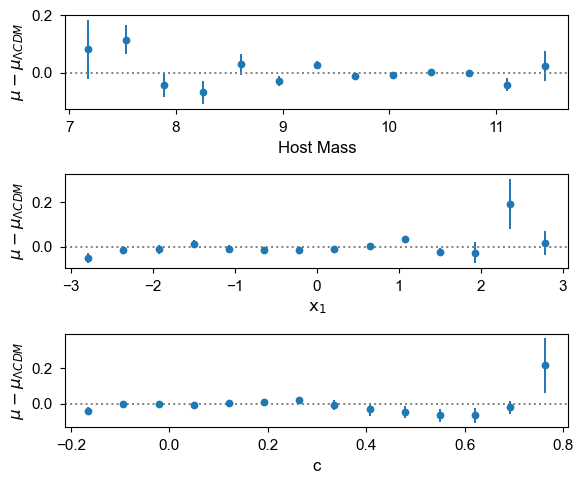

In [44]:
zcut = saltpars["z"]<0.06
allcut = saltpar_cuts & zcut

make_bined_mures_par_plot(allcut)

plt.savefig('paper_figs/mures_vs_par.png')

### Table 3

In [45]:
def calculate_median_cadence(mjd):
    mjd = np.sort(mjd)
    mjd_diff = np.diff(mjd)
    return np.median(mjd_diff)

In [46]:
#caculate nobs, ndetections

for f in "gri":
    lc_to_show = lightcurves_after_spec_selection.dropna(subset="lc")
    lc_to_show = lc_to_show.query("lc.infobits == 0").dropna(subset="lc")    
    data_to_show = lcdata.query("lc.pass_flag_filter == True").dropna(subset="lc")
    data_to_show["lc.detection_flag"] = data_to_show["lc.pass_snr_detection"]
    
    t_min_obslog,t_max_obslog = 58288.171875, 59273.5546875
    data_to_show = data_to_show.query(f"lc.mjd>= {t_min_obslog} & lc.mjd <= {t_max_obslog}").dropna(subset="lc")

    lc_to_show["lc.phase"] =  (lc_to_show["lc.mjd"] - lc_to_show["t0"])/(1.+lc_to_show["z"])
    data_to_show["lc.phase"] = (data_to_show["lc.mjd"] - data_to_show["t0"])/(1.+data_to_show["redshift"])
    
    lc_to_show["lc"] = lc_to_show["lc"].nest[lc_to_show["lc.filter"] == f]
    data_to_show["lc"] = data_to_show["lc"].nest[data_to_show["lc.filter"] == "ztf"+f]

    nobs_sim = lc_to_show['lc.mjd'].count()
    nobs_data = data_to_show['lc.mjd'].count()

    ndet_sim = lc_to_show.query("lc.detection_flag == True").dropna(subset="lc")['lc.mjd'].count()
    ndet_data = data_to_show.query("lc.detection_flag == True").dropna(subset="lc")['lc.mjd'].count()
 
    ndet_sim_window = lc_to_show.query("lc.detection_flag == True & lc.phase < 50 & lc.phase > -20").dropna(subset="lc")['lc.mjd'].count()
    ndet_data_window = data_to_show.query("lc.detection_flag == True & lc.phase < 50 & lc.phase > -20").dropna(subset="lc")['lc.mjd'].count()
    
    avg_nobs_sim = nobs_sim/len(lc_to_show)
    avg_nobs_data = nobs_data/len(data_to_show)
    avg_ndet_sim = ndet_sim/len(lc_to_show)
    avg_ndet_data = ndet_data/len(data_to_show)
    avg_ndet_sim_win = ndet_sim_window/len(lc_to_show)
    avg_ndet_data_win = ndet_data_window/len(data_to_show)
    
    avg_cadence_sim = lc_to_show.reduce(calculate_median_cadence,"lc.mjd")
    avg_cadence_data = data_to_show.reduce(calculate_median_cadence,"lc.mjd")
    
    avg_cadence_sim_det = lc_to_show.query("lc.detection_flag==True").reduce(calculate_median_cadence,"lc.mjd")
    avg_cadence_data_det = data_to_show.query("lc.detection_flag==True").reduce(calculate_median_cadence,"lc.mjd")

    print(f"filter = {f}")
    print("     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   ")

    print(f" sim |{len(lc_to_show)} | {nobs_sim} | {ndet_sim}  | {ndet_sim_window} | {avg_nobs_sim:.2f}  | {avg_ndet_sim:.2f} | {avg_ndet_sim_win:.2f} |{avg_cadence_sim.median()[0]:.2f} | {avg_cadence_sim_det.median()[0]:.2f}")
    print(f" data|{len(data_to_show)} | {nobs_data} | {ndet_data}  | {ndet_data_window} | {avg_nobs_data:.2f} | {avg_ndet_data:.2f} | {avg_ndet_data_win:.2f} |{avg_cadence_data.median()[0]:.2f} |{avg_cadence_data_det.median()[0]:.2f}")


filter = g
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4690 | 1554601 | 102779  | 92078 | 331.47  | 21.91 | 19.63 |1.04 | 2.03
 data|3592 | 1290586 | 104081  | 85181 | 359.29 | 28.98 | 23.71 |1.02 |1.99
filter = r
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4690 | 2091885 | 181391  | 149580 | 446.03  | 38.68 | 31.89 |0.98 | 1.18
 data|3592 | 1676667 | 165462  | 133993 | 466.78 | 46.06 | 37.30 |0.96 |1.10
filter = i
     |Nevent|N_obs    | N_det | N_det,win  |  <N_obs>      | <N_det>   | <N_det,win> | Median Cadence  | Median Detection Cadence   
 sim |4690 | 298854 | 23119  | 19801 | 63.72  | 4.93 | 4.22 |3.96 | 4.01
 data|3592 | 228228 | 18237  | 15808 | 63.54 | 5.08 | 4.40 |3.99 |4.58
